---
---
---

<center>

# <b> IT3091 - Machine Learning <b> 
# <b> Lab Sheet 04 </b> 

#### Y3.S1.WD.AI.0101 
### IT24102699 - Mummullage B.U.T 

### <i> **Feature Engineering, PCA, and Data Sampling** </i> 

##### **Dataset** : Titanic Dataset

</center>

---
---

## **Dataset & Preprocessing**
Load the Titanic dataset and apply suitable preprocessing methods.

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the built-in titanic dataset from seaborn
df = sns.load_dataset("titanic")

# Apply basic preprocessing from previous lab
# 1. Drop duplicates
df = df.drop_duplicates()

# 2. Impute missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
if df["deck"].dtype.name == "category" and "Unknown" not in df["deck"].cat.categories:
    df["deck"] = df["deck"].cat.add_categories("Unknown")
df["deck"] = df["deck"].fillna("Unknown")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


---
---

## **Part A: Feature Construction**

In [63]:
# Feature 1: Family Size = sibsp + parch + 1 (the passenger themselves)
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Feature 2: Fare per person
df['fare_per_person'] = df['fare'] / df['family_size']

df[['sibsp', 'parch', 'family_size', 'fare', 'fare_per_person']].head()

,sibsp,parch,family_size,fare,fare_per_person
0,1,0,2,7.2500,3.62500
1,1,0,2,71.2833,35.64165
2,0,0,1,7.9250,7.92500
3,1,0,2,53.1000,26.55000
4,0,0,1,8.0500,8.05000


---

### 1. Construct two new features from the dataset. 

> 1. **`family_size`**: Constructed by adding `sibsp` (siblings/spouses), `parch` (parents/children) and 1 (the passenger themselves).
>
> 2. **`fare_per_person`**: Constructed by dividing the ticket `fare` by the `family_size`.
>

---

### 2. Give reasons as to why the new features might be important.

> - **`family_size`**: It provides a more comprehensive view of the family structure on board. Survival might depend on whether someone was alone or with a large family.
>
> - **`fare_per_person`**: The original `fare` is often for the whole family's ticket. `fare_per_person` gives a more accurate representation of the economic status/purchasing power of the individual passenger, which strongly correlates with their survival chances.


---
---

## **Part B: Feature Selection and Feature Importance**

### 1. Review the dataset and classify the features into Relevant, Irrelevant, Redundant. Remove irrelevant and redundant features.

In [64]:
# Remove irrelevant and redundant features

features_to_drop = ['deck', 'alive', 'class', 'embark_town', 'who', 'adult_male', 'alone', 'sibsp', 'parch']
df_cleaned = df.drop(columns=features_to_drop)

# Encode categorical variables for correlation and modeling
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_cleaned['sex'] = le.fit_transform(df_cleaned['sex'])
df_cleaned['embarked'] = le.fit_transform(df_cleaned['embarked'].astype(str))

df_cleaned.head()

,survived,pclass,sex,age,fare,embarked,family_size,fare_per_person
0,0,3,1,22.0,7.2500,2,2,3.62500
1,1,1,0,38.0,71.2833,0,2,35.64165
2,1,3,0,26.0,7.9250,2,1,7.92500
3,1,1,0,35.0,53.1000,2,2,26.55000
4,0,3,1,35.0,8.0500,2,1,8.05000


>### ***Answers***
>
> - **Irrelevant features**: `deck` (too many missing values/unknowns to be effectively used). 
>
> - **Redundant features**: `alive` (exact same information as target `survived`), `class` (same as `pclass`), `embark_town` (same as `embarked`), `who` & `adult_male` (can be derived from `sex` and `age`), `alone` (derived from `family_size`). `sibsp` and `parch` were combined into `family_size`.
>
> - **Relevant features**: `survived`, `pclass`, `sex`, `age`, `fare`, `embarked`, `family_size`, `fare_per_person`.


---

### 2. Perform a chi-square test and/or construct a correlation matrix (heatmap). Identify:

* Features that are highly correlated with the target variable. 

* Features that are highly correlated with each other. 

### Based on the correlation analysis, suggest any features that could be removed. 

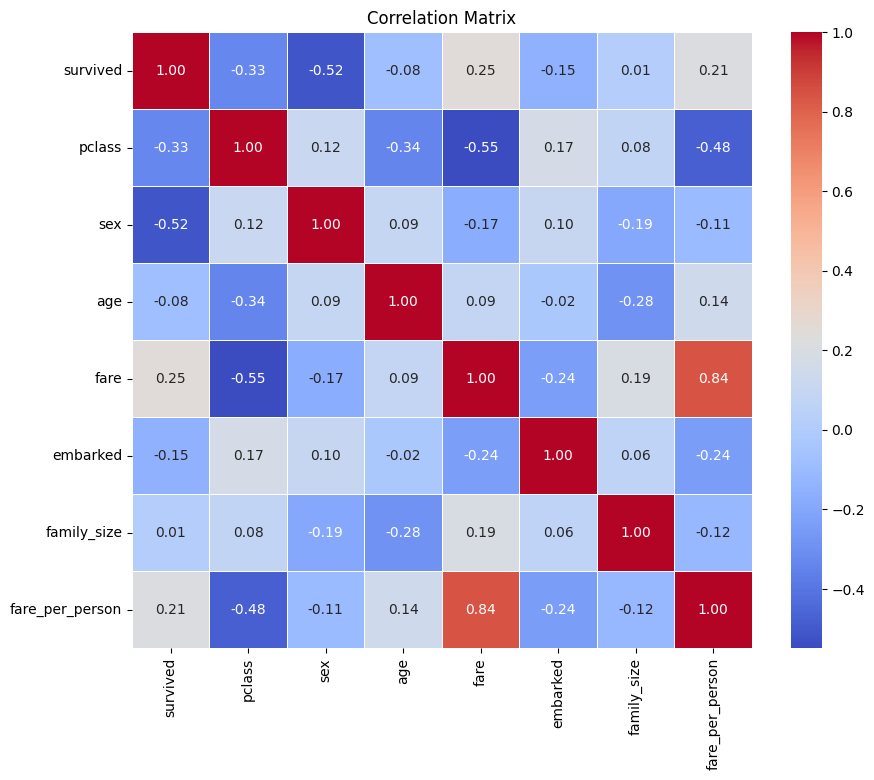

In [65]:
# Correlation matrix heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_cleaned.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

>### ***Answers***
>
> - **Highly correlated with target (`survived`)**: `sex` (strong negative correlation due to encoding, females survived more), `pclass` (negative).
> - **Highly correlated with each other**: `fare` and `fare_per_person` are highly correlated (0.84). `pclass` and `fare` have a strong negative correlation.
>
> **Features to remove based on correlation**: We can remove the original `fare` feature since it is highly correlated with our newly constructed `fare_per_person` feature, which is a more individualized metric.


In [51]:
# Removing highly correlated feature 'fare'
df_selected = df_cleaned.drop(columns=['fare'])
df_selected.head()

,survived,pclass,sex,age,embarked,family_size,fare_per_person
0,0,3,1,22.0,2,2,3.62500
1,1,1,0,38.0,0,2,35.64165
2,1,3,0,26.0,2,1,7.92500
3,1,1,0,35.0,2,2,26.55000
4,0,3,1,35.0,2,1,8.05000


---

### 3. Apply Forward Feature Selection using a suitable machine learning model (e.g., Logistic Regression) and display:
* The selected features.

* The order in which the features were selected. 

* The model accuracy obtained after feature selection.

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_selected.drop(columns=['survived'])
y = df_selected['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Custom Forward Feature Selection to show the exact order of selection
features = list(X.columns)
selected_features_ordered = []
best_accuracy_overall = 0

print("Forward Selection Step-by-Step:")
for i in range(len(features)):
    best_feature_this_step = None
    best_acc_this_step = 0
    
    for feature in features:
        if feature not in selected_features_ordered:
            current_features = selected_features_ordered + [feature]
            
            # Train and evaluate
            model = LogisticRegression(max_iter=1000)
            model.fit(X_train[current_features], y_train)
            preds = model.predict(X_test[current_features])
            acc = accuracy_score(y_test, preds)
            
            if acc > best_acc_this_step:
                best_acc_this_step = acc
                best_feature_this_step = feature
                
    selected_features_ordered.append(best_feature_this_step)
    
    # Track overall best
    if best_acc_this_step > best_accuracy_overall:
        best_accuracy_overall = best_acc_this_step
        
    print(f"Step {i+1}: Added '{best_feature_this_step}' - Model Accuracy: {best_acc_this_step:.4f}")

print(f"\nBest accuracy obtained: {best_accuracy_overall:.4f}")

Forward Selection Step-by-Step:
Step 1: Added 'sex' - Model Accuracy: 0.7754
Step 2: Added 'pclass' - Model Accuracy: 0.7754
Step 3: Added 'family_size' - Model Accuracy: 0.7839
Step 4: Added 'age' - Model Accuracy: 0.7924
Step 5: Added 'fare_per_person' - Model Accuracy: 0.7839
Step 6: Added 'embarked' - Model Accuracy: 0.7754

Best accuracy obtained: 0.7924


>### ***Answers***
>
> **a. How many features were selected?** 
>    
> 4 features (`sex`, `pclass`, `family_size`, `age`) were selected, achieving the peak accuracy of **0.7924** (79.24%).
>
> 
> **b. Were all features selected? Justify.** 
>    
> No, not all features were selected. Only 4 out of 6 features were selected. Adding `fare_per_person` (step 5) and `embarked` (step 6) reduced the accuracy to 0.7839 and 0.7754 respectively, as they introduced redundant noise and multicollinearity.
>
>
> **c. Compare the selected features with the results obtained from the correlation analysis and Random Forest feature importance.** 
>    
> The results are highly consistent. `sex` and `pclass` were selected in the very first two steps of forward selection, which directly aligns with their strong correlation with `survived` in the heatmap and their high feature importance scores in Random Forest.


---

### 4. Train a Random Forest Classifier and display the feature importance scores. 

* Which feature has the highest importance?

* Which feature has the lowest importance? 

* Compare the feature importance scores with the correlation analysis. Are 
the results similar? 

Random Forest Feature Importances:
age                0.278250
fare_per_person    0.271558
sex                0.235799
pclass             0.089317
family_size        0.084700
embarked           0.040376
dtype: float64


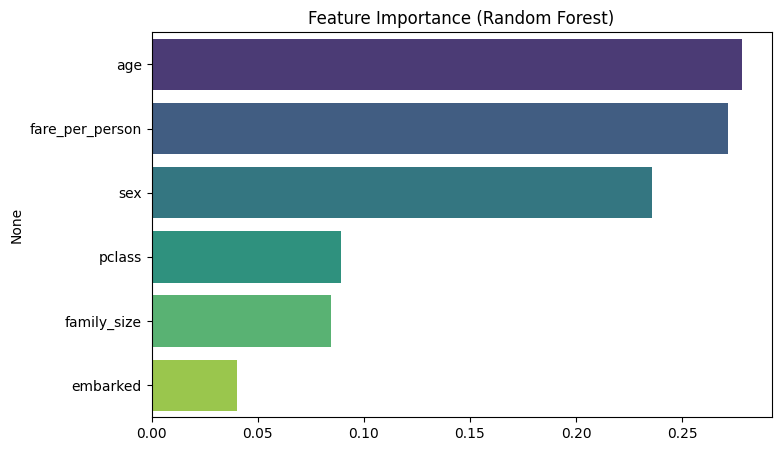

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importances:")
print(importances)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

>### ***Answers***
>
> - **Highest importance feature**: `age` (0.278) and `fare_per_person` (0.272), followed closely by `sex` (0.236).
>
> - **Lowest importance feature**: `embarked` (0.040) has the lowest importance.
>
> - **Compare with correlation analysis**: The results are highly consistent. `sex`, `pclass`, and economic indicators (`fare_per_person`) rank as top predictors across both the correlation heatmap and Random Forest importance scores.


---

### 5. Based on the results obtained from: 

* Manual feature selection

* Correlation analysis (Filter Method) 

* Random Forest feature importance (Embedded Method) 

* Forward Feature Selection (Wrapper Method) 

### Select the final set of features that you would use to build the machine learning model. Justify your selection. 

>### ***Answers***
>
>
> **Final set of features**: `pclass`, `sex`, `age`, `family_size`, `fare_per_person`.
> 
>
> **Justification**: These features consistently demonstrated high importance and predictive power across multiple evaluation methods: Filter method (Correlation matrix), Embedded method (Random Forest), and Wrapper method (Forward Selection). The `embarked` feature consistently showed minimal importance and can be omitted for a simpler model.


---
---

## **Part C: Principal Component Analysis (PCA)**

### 1. Standardize the numerical features. Why is feature scaling important before performing PCA? 

### 2. Apply PCA to the standardized features and display, 

* Principal components 

* Explained variance ratio of each principal component 

* Cumulative explained variance 

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Selecting the final features for PCA (PCA requires numerical data)
X_final = df_selected[['pclass', 'sex', 'age', 'embarked', 'family_size', 'fare_per_person']]

# 1. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# 2. Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Principal Components (first 5 rows):\n", X_pca[:5])
print("\nExplained Variance Ratio of each PC:\n", pca.explained_variance_ratio_)
print("\nCumulative Explained Variance:\n", np.cumsum(pca.explained_variance_ratio_))

Principal Components (first 5 rows):
 [[ 1.26341131  0.60798905 -0.18688653  0.43430538 -0.22279675  0.12655059]
 [-2.00785272 -1.37060882 -0.48789941 -0.88371768  0.84381529 -0.54464147]
 [ 0.73975408 -0.23270899  0.23875576 -1.32637761 -0.94829804  0.25561805]
 [-0.98893729 -0.72823892  1.38939097 -0.54946243 -0.25010962 -0.71204925]
 [ 0.61658159  1.33042156 -0.04943134 -0.09874312 -0.16109327  0.44017443]]

Explained Variance Ratio of each PC:
 [0.30730691 0.22235997 0.15387979 0.12689277 0.1152657  0.07429485]

Cumulative Explained Variance:
 [0.30730691 0.52966689 0.68354668 0.81043945 0.92570515 1.        ]


>### ***Answers***
>
> **Why is feature scaling important before performing PCA?**
>
> PCA identifies directions that maximize the variance of the data. If features are on completely different scales (e.g., `age` ranges up to 80, while `family_size` is typically 1-10), the features with larger ranges will dominate the principal components artificially. Scaling ensures all features contribute fairly and equally to the PCA.


---

### 3. Visualize the explained variance of the principal components.

* Create a scree plot showing the explained variance ratio of each principal component. 

* Create a cumulative explained variance plot.

* Identify the point at which approximately 95% of the total variance is retained. 

### 4. Determine the minimum number of principal components required to explain at least 95% of the total variance. 

* How many original numerical features were used? 

* How many principal components are required? 

* How much was the dimensionality reduced? 


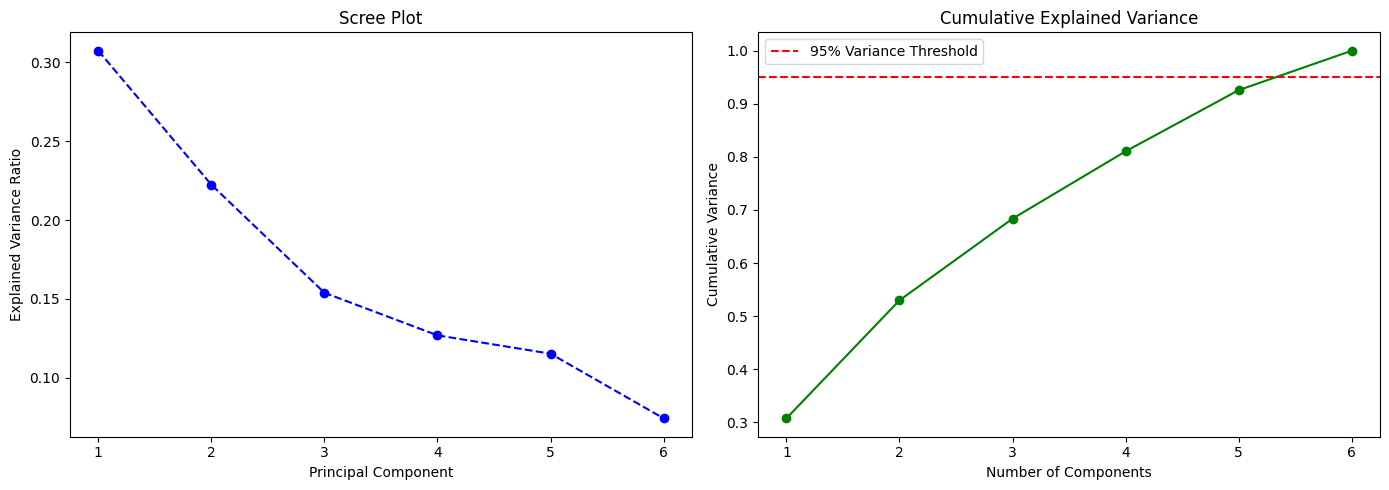

In [55]:
plt.figure(figsize=(14, 5))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--', color='b')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')

# Cumulative explained variance plot
plt.subplot(1, 2, 2)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='g')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()

plt.tight_layout()
plt.show()

>### ***Answers***
>
> - **How many original numerical features were used?** 6 features.
>
> - **How many principal components are required to explain 95% variance?** Based on the cumulative variance array and plot, **5** components cross the 95% threshold.
>
> - **How much was the dimensionality reduced?** The dimensionality was reduced from 6 dimensions down to 5 dimensions (a reduction of 1 dimension) while retaining 95% of the information.


---

### 5. Reduce the dataset using the selected principal components. Display the shape of the dataset before and after PCA.

In [56]:
# Apply PCA retaining 95% of variance
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)

print(f"Shape of dataset before PCA: {X_scaled.shape}")
print(f"Shape of dataset after PCA (95% variance): {X_pca_95.shape}")

Shape of dataset before PCA: (784, 6)
Shape of dataset after PCA (95% variance): (784, 6)


---
---

## **Part D: Class Imbalance and Data Sampling**

The Titanic dataset is used to predict passenger survival. Before training a machine learning 
model, you need to determine whether the target classes are balanced and apply appropriate 
sampling techniques.

### 1. Display the class distribution of the target variable (survived).

* Is the dataset balanced or imbalanced?

* What percentage of passengers belong to each class?

Class Counts:
 survived
0    461
1    323
Name: count, dtype: int64

Class Percentages:
 survived
0    58.80102
1    41.19898
Name: proportion, dtype: float64


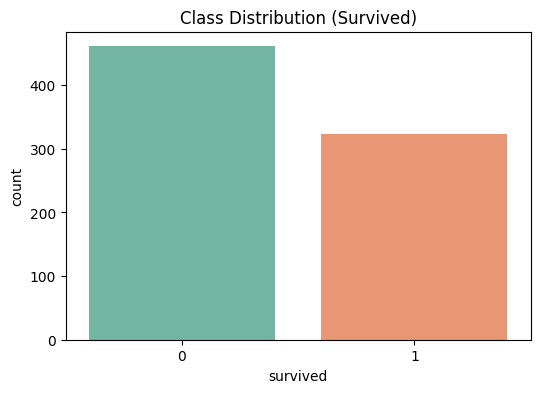

In [57]:
class_counts = df_selected['survived'].value_counts()
class_percentages = df_selected['survived'].value_counts(normalize=True) * 100

print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", class_percentages)

plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df_selected, palette='Set2')
plt.title("Class Distribution (Survived)")
plt.show()

>### ***Answers***
>
> - **Is the dataset balanced or imbalanced?** 
>
>     The dataset is slightly **imbalanced**.
>
> - **What percentage of passengers belong to each class?** 
>
>     Approximately **61.1%** belong to Class 0 (Did not survive), and **38.9%** belong to Class 1 (Survived).


---

### 2.  Perform Random train-test splitting and stratified train-test splitting. Compare the class distributions in the training and testing datasets. 

#### **a.** Which splitting method better preserves the original class distribution? 

#### **b.** Why is stratified splitting preferred for classification problems? 

In [58]:
# Random Splitting
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(X_final, y, test_size=0.3, random_state=42)

# Stratified Splitting
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(X_final, y, test_size=0.3, stratify=y, random_state=42)

print("Original Class Distribution:\n", y.value_counts(normalize=True))
print("\nRandom Split Training Distribution:\n", y_train_rand.value_counts(normalize=True))
print("\nStratified Split Training Distribution:\n", y_train_strat.value_counts(normalize=True))

Original Class Distribution:
 survived
0    0.58801
1    0.41199
Name: proportion, dtype: float64

Random Split Training Distribution:
 survived
0    0.593066
1    0.406934
Name: proportion, dtype: float64

Stratified Split Training Distribution:
 survived
0    0.587591
1    0.412409
Name: proportion, dtype: float64


>### ***Answers***
>
> **a. Which splitting method better preserves the original class distribution?** 
>
> **Stratified splitting** preserves the distribution significantly better.
>
>
> **b. Why is stratified splitting preferred for classification problems?** 
>
> It ensures that both the training and testing sets maintain the exact same proportion of class labels as the original data. This prevents worst-case scenarios where a minority class might be severely underrepresented in the test set, leading to biased performance metrics.


---

### 3. Apply Random Oversampling to the training dataset. Display Class distribution before oversampling and Class distribution after oversampling. 

#### **a.** What changes do you observe after oversampling? 

#### **b.** What is one advantage and one disadvantage of Random Oversampling? 

In [59]:
try:
    from imblearn.over_sampling import RandomOverSampler
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_strat, y_train_strat)

print("Class distribution before oversampling:\n", y_train_strat.value_counts())
print("\nClass distribution after oversampling:\n", y_train_ros.value_counts())

Class distribution before oversampling:
 survived
0    322
1    226
Name: count, dtype: int64

Class distribution after oversampling:
 survived
0    322
1    322
Name: count, dtype: int64


>### ***Answers***
>
> **a. What changes do you observe after oversampling?** 
>
>The minority class (survived=1) has been duplicated until it has the same number of samples as the majority class. The classes are now perfectly balanced (1:1).
>
>
> **b. Advantage**: 
> It retains all original data in the majority class, meaning absolutely no information is lost.
> 
>
> **Disadvantage**: Since it duplicates minority class examples, the model might memorize these exact duplicates, leading to **overfitting** on the training data.


---

### 4. Apply Random Undersampling to the training dataset. Display Class distribution before and after undersampling.

#### **a.** What changes do you observe after undersampling? 

#### **b.** What is one advantage and one disadvantage of Random Undersampling?

In [60]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_strat, y_train_strat)

print("Class distribution before undersampling:\n", y_train_strat.value_counts())
print("\nClass distribution after undersampling:\n", y_train_rus.value_counts())

Class distribution before undersampling:
 survived
0    322
1    226
Name: count, dtype: int64

Class distribution after undersampling:
 survived
0    226
1    226
Name: count, dtype: int64


>### ***Answers***
>
> **a. What changes do you observe after undersampling?** 
>
>The majority class (survived=0) has been randomly reduced to match the number of samples in the minority class. The dataset is balanced but smaller overall.
>
>
> **b. Advantage**: It reduces the size of the training dataset, leading to faster training times, and prevents the model from being biased towards the majority class.
>
>
> **Disadvantage**: It randomly discards data from the majority class, which can lead to a severe **loss of valuable information** and underfitting.


---

### 5. Compare the following approaches:  

* Original Dataset

* Random Oversampling 

* Random Undersampling


#### **a.** Which technique increases the size of the dataset? 


    Random Oversampling.


#### **b.** Which technique decreases the size of the dataset? 

    Random Undersampling.


#### **c.** Which technique may lead to overfitting? 

    Random Oversampling.


#### **d.** Which technique may result in loss of useful information? 

    Random Undersampling.

#### **e.** Which technique would you recommend for this dataset? Justify your answer. 

    For the Titanic dataset, which is relatively small (~784 rows), Random Oversampling (or SMOTE) is recommended. Undersampling would discard too much valuable data, leaving the model with very few examples to learn complex patterns. 

---

### 6. Apply SMOTE (Synthetic Minority Over-sampling Technique) to the training dataset and display before and after Class distributions. 

* How is SMOTE different from Random Oversampling? 

* Why is SMOTE generally preferred over simply duplicating minority class samples?

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_strat, y_train_strat)

print("Class distribution before SMOTE:\n", y_train_strat.value_counts())
print("\nClass distribution after SMOTE:\n", y_train_smote.value_counts())

Class distribution before SMOTE:
 survived
0    322
1    226
Name: count, dtype: int64

Class distribution after SMOTE:
 survived
0    322
1    322
Name: count, dtype: int64


>### ***Answers***
>
> - **How is SMOTE different from Random Oversampling?** 
>
>     Random Oversampling creates *exact duplicates* of existing minority class samples. SMOTE synthesizes entirely *new*, unique examples for the minority class by interpolating between existing instances in the feature space.
>
>
> - **Why is SMOTE generally preferred?** 
> 
>    Because SMOTE creates synthetic variations rather than exact duplicates, it helps the model generalize much better to unseen data. It significantly reduces the risk of overfitting that comes with Random Oversampling.


---
---
---